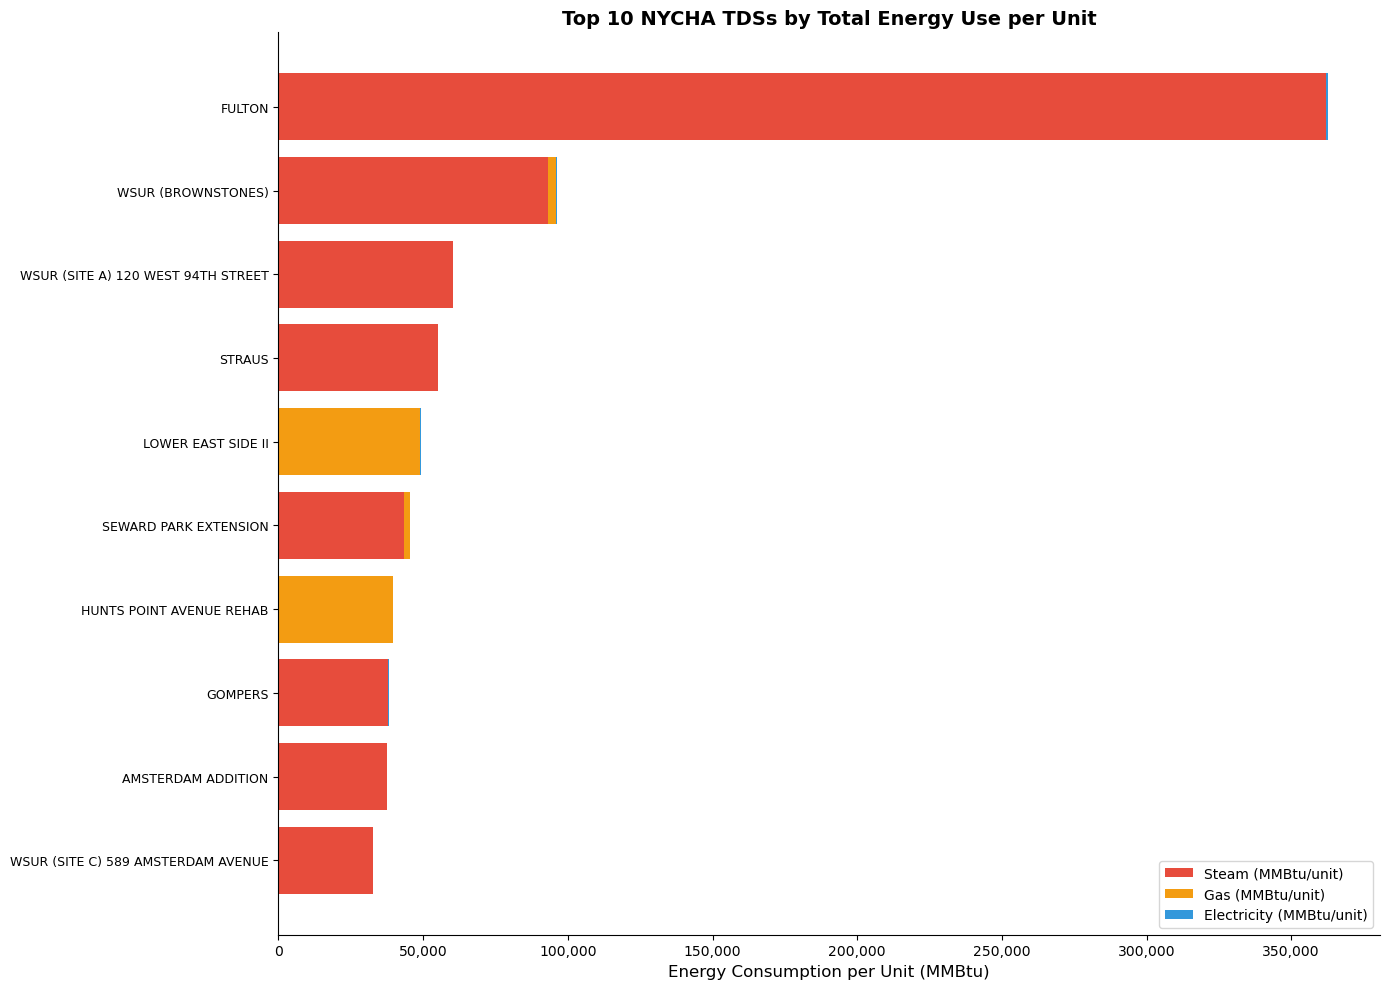

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

base = Path().resolve().parent
df = pd.read_csv(base / "cleaned_data/combined_utilities_2024.csv")

# Use unitsres, falling back to unitstotal when NaN
df['units'] = df['unitsres'].fillna(df['unitstotal'])

# Group by TDS — aggregate total energy (per-unit × units) then divide by total units
tds = df.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'total_units': g['units'].sum(),
        'total_steam_mmbtu': (g['steam_mmbtu_per_unit'].fillna(0) * g['units']).sum(),
        'total_gas_mmbtu': (g['gas_mmbtu_per_unit'].fillna(0) * g['units']).sum(),
        'total_elec_mmbtu': (g['electricity_mmbtu_per_unit'].fillna(0) * g['units']).sum(),
    }),
    include_groups=False,
).reset_index(drop=True)

# Recalculate per-unit values at the TDS level
tds['steam_mmbtu_per_unit'] = tds['total_steam_mmbtu'] / tds['total_units']
tds['gas_mmbtu_per_unit'] = tds['total_gas_mmbtu'] / tds['total_units']
tds['elec_mmbtu_per_unit'] = tds['total_elec_mmbtu'] / tds['total_units']
tds['total_energy_mmbtu_per_unit'] = (
    tds['steam_mmbtu_per_unit'] + tds['gas_mmbtu_per_unit'] + tds['elec_mmbtu_per_unit']
)

# Top 10 TDSs by total energy per unit
top10 = tds.nlargest(10, 'total_energy_mmbtu_per_unit').sort_values('total_energy_mmbtu_per_unit', ascending=True)

steam_vals = top10['steam_mmbtu_per_unit'].fillna(0).values
gas_vals = top10['gas_mmbtu_per_unit'].fillna(0).values
elec_vals = top10['elec_mmbtu_per_unit'].fillna(0).values
labels = top10['development'].values

# Horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(14, 10))
y = np.arange(len(labels))

ax.barh(y, steam_vals, label='Steam (MMBtu/unit)', color='#e74c3c')
ax.barh(y, gas_vals, left=steam_vals, label='Gas (MMBtu/unit)', color='#f39c12')
ax.barh(y, elec_vals, left=steam_vals + gas_vals, label='Electricity (MMBtu/unit)', color='#3498db')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Energy Consumption per Unit (MMBtu)', fontsize=12)
ax.set_title('Top 10 NYCHA TDSs by Total Energy Use per Unit', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()